# 3D Scanner Pipeline

Acquisition, calibration, point cloud reconstruction, and surface meshing.
Three reconstruction methods are compared in section 5: Poisson, SDF, and neural implicit (IGR).


In [1]:
%pip install opencv-python matplotlib open3d scikit-image scipy plotly
%pip install torch --index-url https://download.pytorch.org/whl/cpu

  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
   ---------------------------------------- 0.0/69.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.2 MB 4.2 MB/s eta 0:00:17
   - -------------------------------------- 2.1/69.2 MB 6.9 MB/s eta 0:00:10
   -- ------------------------------------- 3.7/69.2 MB 7.0 MB/s eta 0:00:10
   --- ------------------------------------ 5.5/69.2 MB 7.6 MB/s eta 0:00:09
   ---- ----------------------------------- 7.1/69.2 MB 7.9 MB/s eta 0:00:08
   ----- ---------------------------------- 8.7/69.2 MB 7.8 MB/s eta 0:00:08
   ------ --------------------------------- 10.5/69.2 MB 7.8 MB/s eta 0:00:08
   ------- -------------------------------- 12.3/69.2 MB 8.0 MB/s eta 0:00:08
   -------- ------------------------------- 13.9/69.2 MB 8.0 MB/s eta 0:00:07
   --------- ------------------------------ 16.0/69.2 MB 8.1 MB/s eta 0:00:07
   ---------- ----------------------------- 17.8/69.2 MB 8.2 MB/s eta 0:00:07
   ----------- -

In [2]:
from pathlib import Path
import importlib
import json
import subprocess
import sys

try:
    import cv2
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    import numpy as np
    import open3d as o3d
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError(
        "Install notebook dependencies: pip install opencv-python matplotlib open3d scikit-image scipy plotly"
    ) from exc

import reconstruct as reconstruct_module
importlib.reload(reconstruct_module)

ROOT = Path.cwd()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)

dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

print(f"Dataset: {dataset_name}")


def point_cloud_from_array(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    return pcd


def plot_points(points, title, limit=12000):
    if len(points) == 0:
        raise ValueError("No points to plot")

    count = min(limit, len(points))
    rng = np.random.default_rng(0)
    sample = points[rng.choice(len(points), count, replace=False)]

    fig = go.Figure(go.Scatter3d(
        x=sample[:, 0], y=sample[:, 1], z=sample[:, 2],
        mode="markers",
        marker=dict(size=1.5, color=sample[:, 2], colorscale="Viridis", opacity=0.8),
    ))
    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        margin=dict(l=0, r=0, t=40, b=0),
        height=650,
    )
    fig.show()


def plot_mesh(mesh, title, max_triangles=120000):
    mesh_to_plot = mesh
    if len(mesh_to_plot.triangles) > max_triangles:
        mesh_to_plot = mesh_to_plot.simplify_quadric_decimation(max_triangles)
        mesh_to_plot.remove_degenerate_triangles()
        mesh_to_plot.remove_duplicated_triangles()
        mesh_to_plot.remove_duplicated_vertices()
    mesh_to_plot.compute_vertex_normals()

    verts = np.asarray(mesh_to_plot.vertices)
    tris  = np.asarray(mesh_to_plot.triangles)
    vnorm = np.asarray(mesh_to_plot.vertex_normals)

    # Simple diffuse shading: weight each vertex by how much it faces the light.
    light = np.array([0.5, 0.5, 1.0], dtype=np.float64)
    light /= np.linalg.norm(light)
    intensity = np.clip(vnorm @ light, 0, 1) * 0.6 + 0.35

    fig = go.Figure(go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=tris[:, 0],  j=tris[:, 1],  k=tris[:, 2],
        intensity=intensity,
        colorscale="Blues_r",
        showscale=False,
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.3, roughness=0.5),
        lightposition=dict(x=1, y=1, z=2),
    ))
    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        margin=dict(l=0, r=0, t=40, b=0),
        height=650,
    )
    fig.show()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Dataset: suzanne


## 0. Camera Poses & Turntable Calibration

Use sampled ChArUco board frames from `scanner_asteroid_new_checkerboard` to estimate camera-to-board poses, camera extrinsics in the fitted turntable frame, and the turntable rotation axis and center.

In [3]:
cam_cal_path = ROOT / f"camera_calibration_{dataset_name}.json"

result = subprocess.run(
    [sys.executable, "calibrate_camera.py", "--max-frames", "360", "--min-corners", "35",
     "--output", str(cam_cal_path), "--update-config"],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
result.check_returncode()

with open(cam_cal_path) as f:
    cam_cal = json.load(f)

with open(ROOT / "config.json") as f:
    root_config = json.load(f)
dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

K_pose = np.array(cam_cal["camera_matrix"])

rms_rp  = cam_cal["rms_reprojection"]
p95_rp  = cam_cal["p95_reprojection"]
p_used  = cam_cal["poses_used"]
f_samp  = cam_cal["frames_sampled"]
f_total = cam_cal["frames_total"]
p_axis  = cam_cal["poses_used_for_axis"]
dc_w    = [round(v, 4) for v in cam_cal["disk_center_world"]]
da_w    = [round(v, 4) for v in cam_cal["disk_axis_world"]]
da_sprd = cam_cal["disk_axis_spread_deg"]
est     = cam_cal["estimated_extrinsics"]
cam_loc = [round(v, 4) for v in est["camera_location_world"]]

print(f"Pose reprojection RMS : {rms_rp:.4f} px")
print(f"Pose reprojection p95 : {p95_rp:.4f} px")
print(f"Poses used            : {p_used} / {f_samp} sampled / {f_total} total")
print(f"Poses used for axis   : {p_axis}")
print()
print("Camera K used:")
print(f"  fx={K_pose[0,0]:.2f}  fy={K_pose[1,1]:.2f}  cx={K_pose[0,2]:.2f}  cy={K_pose[1,2]:.2f}")
print()
print(f"Disk center (world) : {dc_w}")
print(f"Disk axis   (world) : {da_w}")
print(f"Disk axis spread    : {da_sprd:.3f} deg")
print()
print(f"Estimated camera location: {cam_loc}")


Saved calibration to c:\Users\bosca\Desktop\ComputerVision\camera_calibration_suzanne.json
Pose reprojection RMS: 0.3974 px
fx=1120.00  fy=1120.00  cx=512.00  cy=512.00
disk_center_world: [-2.8621660204302317e-11, -2.9839398692340627e-12, 4.9470671542676634e-11]
disk_axis_world:   [2.3805860061714806e-11, 9.057643524369942e-12, 1.0]
disk_axis_spread:  0.198 deg
estimated_camera_location: [1.0008363991877134, -5.890674264386888, 3.3545562679482863]
poses used: 338 / 360 sampled / 360 total
Updated config.json with estimated camera extrinsics and canonical disk frame.

Pose reprojection RMS : 0.3974 px
Pose reprojection p95 : 0.8699 px
Poses used            : 338 / 360 sampled / 360 total
Poses used for axis   : 338

Camera K used:
  fx=1120.00  fy=1120.00  cx=512.00  cy=512.00

Disk center (world) : [-0.0, -0.0, 0.0]
Disk axis   (world) : [0.0, 0.0, 1.0]
Disk axis spread    : 0.198 deg

Estimated camera location: [1.0008, -5.8907, 3.3546]


## 0b. Laser Plane Calibration

Use 4 tilted ChArUco board images (`scanner_asteroid_new_checkerboards`) to fit the laser plane in world coordinates via ray–board intersection + robust SVD plane fit.

In [4]:
laser_cal_path = ROOT / config["calibration"]["laser_calibration_output"]

result = subprocess.run(
    [sys.executable, "calibrate_laser.py", "--update-config"],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
result.check_returncode()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)
dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

with open(laser_cal_path) as f:
    laser_cal = json.load(f)

wp     = laser_cal["world_plane"]
normal = [round(v, 5) for v in wp["normal"]]
pt     = [round(v, 5) for v in wp["point"]]
kept   = laser_cal["kept_points"]
total  = laser_cal["total_points"]

print(f"Laser plane normal (world): {normal}")
print(f"Laser plane point  (world): {pt}")
print(f"Points kept: {kept} / {total}")
print()
for img_info in laser_cal["images"]:
    name    = Path(img_info["image"]).name
    used    = img_info["used_points"]
    corners = img_info["charuco_corners"]
    print(f"  {name}: {used} stripe pts, {corners} ChArUco corners")


Laser calibration points: 5029 / 5110
Normal: [-0.8635979441035395, -0.49682001907253853, -0.08583973199458683]
Point:  [0.04441647527158273, 0.08292015667168062, 0.8628456745138342]
Saved:  laser_calibration_suzanne.json

Laser plane normal (world): [-0.8636, -0.49682, -0.08584]
Laser plane point  (world): [0.04442, 0.08292, 0.86285]
Points kept: 5029 / 5110

  checkerboard_1.png: 194 stripe pts, 70 ChArUco corners
  checkerboard_10.png: 283 stripe pts, 67 ChArUco corners
  checkerboard_11.png: 122 stripe pts, 69 ChArUco corners
  checkerboard_12.png: 150 stripe pts, 70 ChArUco corners
  checkerboard_13.png: 148 stripe pts, 70 ChArUco corners
  checkerboard_14.png: 149 stripe pts, 70 ChArUco corners
  checkerboard_15.png: 235 stripe pts, 70 ChArUco corners
  checkerboard_16.png: 227 stripe pts, 70 ChArUco corners
  checkerboard_17.png: 107 stripe pts, 65 ChArUco corners
  checkerboard_18.png: 113 stripe pts, 69 ChArUco corners
  checkerboard_19.png: 157 stripe pts, 70 ChArUco corners


## 1. Acquisition Frames

render dir: c:\Users\bosca\Desktop\ComputerVision\scanner_suzanne
render glob: suzanne*.png
frames:     360 / 360


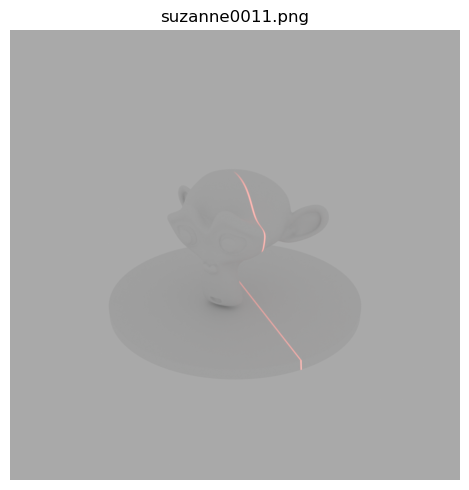

In [5]:
render_dir  = ROOT / paths["input_dir"]
render_glob = paths.get("input_glob", "scan_*.png")
renders     = sorted(render_dir.glob(render_glob))
n_frames    = config["disk"]["n_frames"]

print(f"render dir: {render_dir}")
print(f"render glob: {render_glob}")
print(f"frames:     {len(renders)} / {n_frames}")

assert renders, f"No rendered frames found in {render_dir}"

frame = min(10, len(renders) - 1)
image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(renders[frame].name)
plt.axis("off")
plt.tight_layout()


## 2. Laser Stripe Extraction

masks:  360
coords: 360
stripe points per frame: min 123  mean 250.2  max 279


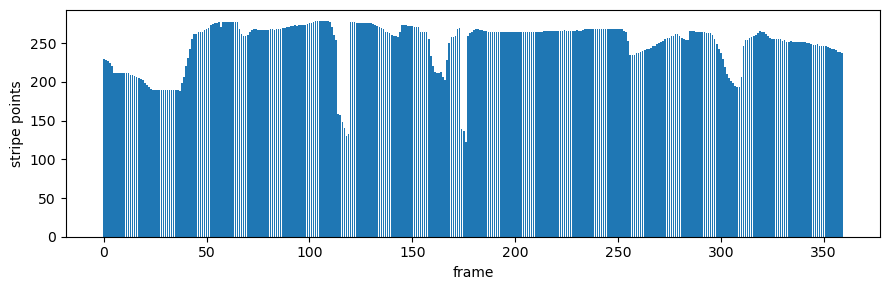

In [6]:
subprocess.run([sys.executable, "extract_stripes.py"], cwd=ROOT, check=True)

mask_glob  = render_glob
coord_glob = Path(render_glob).stem + ".npy"
masks  = sorted((ROOT / paths["stripe_masks_dir"]).glob(mask_glob))
coords = sorted((ROOT / paths["stripe_coords_dir"]).glob(coord_glob))
counts = np.array([len(np.load(path)) for path in coords])

print(f"masks:  {len(masks)}")
print(f"coords: {len(coords)}")
print(f"stripe points per frame: min {counts.min()}  mean {counts.mean():.1f}  max {counts.max()}")

plt.figure(figsize=(9, 3))
plt.bar(range(len(counts)), counts)
plt.xlabel("frame")
plt.ylabel("stripe points")
plt.tight_layout()


## 3. Centerline Check

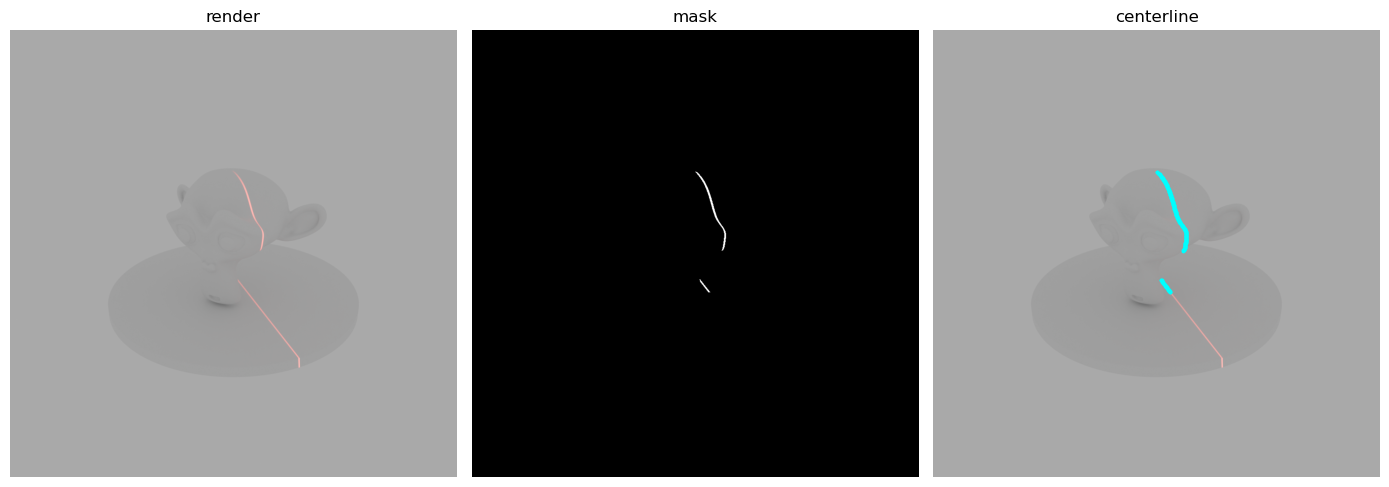

In [7]:
frame = min(10, len(renders) - 1)

image      = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)
mask       = cv2.imread(str(masks[frame]), cv2.IMREAD_GRAYSCALE)
centerline = np.load(coords[frame])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("render")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("mask")
axes[2].imshow(image)
axes[2].scatter(centerline[:, 1], centerline[:, 0], s=3, c="cyan")
axes[2].set_title("centerline")

for ax in axes:
    ax.axis("off")

plt.tight_layout()


## 4. Point Cloud Reconstruction

In [8]:
points = reconstruct_module.reconstruct(config)
point_cloud_path = ROOT / paths["point_cloud"]
reconstruct_module.save_ply(points, point_cloud_path)

print(f"points: {len(points)}")
print(f"saved:  {point_cloud_path}")
print(f"min:    {points.min(axis=0)}")
print(f"max:    {points.max(axis=0)}")
print(f"mean:   {points.mean(axis=0)}")

plot_points(points, "reconstructed point cloud")


points: 74825
saved:  c:\Users\bosca\Desktop\ComputerVision\point_cloud_suzanne.ply
min:    [-0.83142793 -0.8185354   0.12002083]
max:    [1.1515896  0.87097687 1.6892154 ]
mean:   [-0.02871474 -0.04673178  1.2038852 ]


radius p05/p50/p95: [0.15815033 0.55090177 0.75858051]
z      p05/p50/p95: [0.33584095 1.28825283 1.66806793]


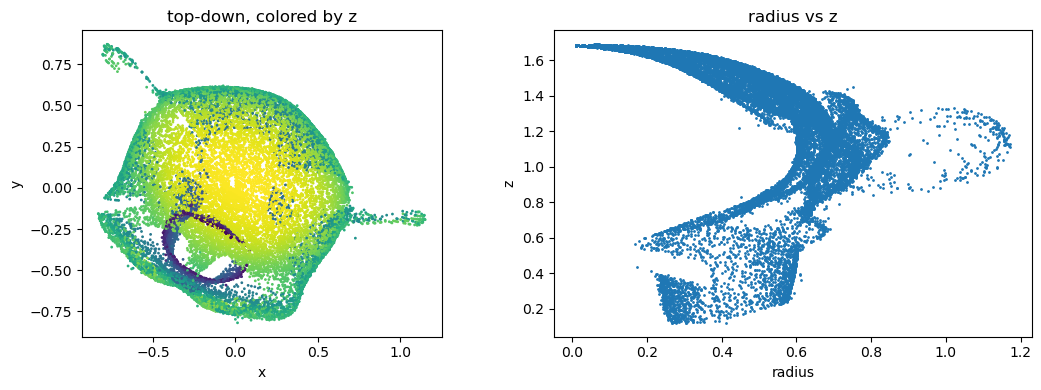

In [9]:
r_xy = np.linalg.norm(points[:, :2], axis=1)
print(f"radius p05/p50/p95: {np.percentile(r_xy, [5, 50, 95])}")
print(f"z      p05/p50/p95: {np.percentile(points[:, 2], [5, 50, 95])}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
idx    = np.random.default_rng(1).choice(len(points), min(20000, len(points)), replace=False)
sample = points[idx]
axes[0].scatter(sample[:, 0], sample[:, 1], c=sample[:, 2], s=1, cmap="viridis")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("top-down, colored by z")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[1].scatter(r_xy[idx], sample[:, 2], s=1)
axes[1].set_title("radius vs z")
axes[1].set_xlabel("radius")
axes[1].set_ylabel("z")
plt.tight_layout()


gt radius p05/p50/p95: [0.51499026 1.47764562 2.00962285]
gt z      p05/p50/p95: [-0.80466812  0.16627048  0.79726862]


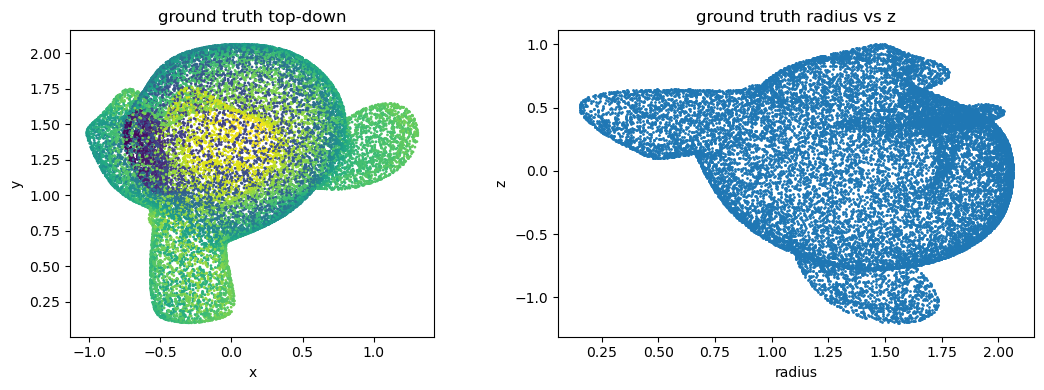

In [10]:
gt_mesh_for_shape = o3d.io.read_triangle_mesh(str(ROOT / paths["ground_truth_mesh"]))
gt_sample_shape   = np.asarray(
    gt_mesh_for_shape.sample_points_uniformly(number_of_points=60000).points
)

gt_radius = np.linalg.norm(gt_sample_shape[:, :2], axis=1)
print(f"gt radius p05/p50/p95: {np.percentile(gt_radius, [5, 50, 95])}")
print(f"gt z      p05/p50/p95: {np.percentile(gt_sample_shape[:, 2], [5, 50, 95])}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
idx_gt  = np.random.default_rng(2).choice(
    len(gt_sample_shape), min(20000, len(gt_sample_shape)), replace=False
)
gt_plot = gt_sample_shape[idx_gt]
axes[0].scatter(gt_plot[:, 0], gt_plot[:, 1], c=gt_plot[:, 2], s=1, cmap="viridis")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("ground truth top-down")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[1].scatter(gt_radius[idx_gt], gt_plot[:, 2], s=1)
axes[1].set_title("ground truth radius vs z")
axes[1].set_xlabel("radius")
axes[1].set_ylabel("z")
plt.tight_layout()


## 5. Reconstruction

Poisson (5a), volumetric SDF with winding number sign (5b), and neural implicit / IGR (5c).


### Tuning utilities

Since all reconstruction models that we will use have hyperparameters that can be tuned, we implement a grid search module. The grid searches below use a smaller Chamfer sample count than the final comparison so they stay practical inside the notebook.


In [18]:
importlib.reload(reconstruct_module)

tuning_dir = ROOT / f"tuning_{dataset_name}"
tuning_dir.mkdir(exist_ok=True)

tuning_sample_count = 8000


def score_mesh(mesh_path, sample_count=tuning_sample_count):
    ground_truth_path = ROOT / paths["ground_truth_mesh"]
    if not ground_truth_path.exists():
        return None

    o3d.utility.random.seed(42)
    recon_s = reconstruct_module.sample_mesh(str(mesh_path), sample_count)
    gt_s = reconstruct_module.sample_mesh(str(ground_truth_path), sample_count)
    gt_s = reconstruct_module.align_by_centroid_scale(gt_s, recon_s)
    gt_s = reconstruct_module.align_by_icp(gt_s, recon_s)
    metrics = reconstruct_module.chamfer_metrics(recon_s, gt_s)
    return metrics


def print_grid_results(title, rows):
    rows = sorted(rows, key=lambda r: r["chamfer_l1_mean"])
    print(title)
    for i, row in enumerate(rows, start=1):
        params = ", ".join(f"{k}={v}" for k, v in row["params"].items())
        print(
            f"{i:02d}. chamfer={row['chamfer_l1_mean']:.5f} "
            f"r->gt={row['reconstruction_to_ground_truth_mean']:.5f} "
            f"gt->r={row['ground_truth_to_reconstruction_mean']:.5f} | {params}"
        )
    return rows[0]


### 5a. Poisson

Poisson reconstruction reconstructs a watertight surface mesh from an oriented point cloud by solving a global Poisson equation whose gradient best matches the input normals.

#### Poisson grid search

Searches octree depth and density trimming. The best row is used by the final Poisson reconstruction cell.


In [19]:
poisson_grid = [
    {"depth": depth, "density_quantile": density_quantile}
    for depth in [8, 9, 10]
    for density_quantile in [0.02, 0.04, 0.06]
]

poisson_results = []
for params in poisson_grid:
    mesh_path = tuning_dir / (
        f"poisson_depth{params['depth']}_density{params['density_quantile']:.2f}.ply"
    )
    mesh = reconstruct_module.reconstruct_surface(points, str(mesh_path), **params)
    metrics = score_mesh(mesh_path)
    if metrics is None:
        print("Ground truth missing; skipping Poisson tuning score.")
        break
    poisson_results.append({"params": params, **metrics})

if poisson_results:
    best_poisson = print_grid_results("Poisson tuning", poisson_results)
    best_poisson_params = best_poisson["params"]
else:
    best_poisson_params = {"depth": 9, "density_quantile": 0.04}

best_poisson_params


Poisson tuning
01. chamfer=0.11090 r->gt=0.11468 gt->r=0.10712 | depth=8, density_quantile=0.02
02. chamfer=0.11106 r->gt=0.11481 gt->r=0.10730 | depth=10, density_quantile=0.02
03. chamfer=0.11159 r->gt=0.11610 gt->r=0.10707 | depth=9, density_quantile=0.02
04. chamfer=0.11332 r->gt=0.11490 gt->r=0.11175 | depth=10, density_quantile=0.04
05. chamfer=0.11357 r->gt=0.11539 gt->r=0.11175 | depth=9, density_quantile=0.04
06. chamfer=0.11358 r->gt=0.11577 gt->r=0.11140 | depth=8, density_quantile=0.04
07. chamfer=0.11529 r->gt=0.11607 gt->r=0.11451 | depth=10, density_quantile=0.06
08. chamfer=0.11565 r->gt=0.11767 gt->r=0.11363 | depth=9, density_quantile=0.06
09. chamfer=0.11571 r->gt=0.11554 gt->r=0.11589 | depth=8, density_quantile=0.06


{'depth': 8, 'density_quantile': 0.02}

In [20]:
importlib.reload(reconstruct_module)

cam_location = config["camera"].get("location", None)
recon_base = ROOT / paths["reconstructed_mesh"]

mesh_path_poisson = recon_base.with_name(recon_base.stem + "_poisson" + recon_base.suffix)
mesh_obj_poisson = mesh_path_poisson.with_suffix(".obj")

mesh_poisson = reconstruct_module.reconstruct_surface(
    points, str(mesh_path_poisson),
    camera_location=cam_location,
    **best_poisson_params,
)
reconstruct_module.export_mesh(mesh_poisson, str(mesh_obj_poisson))

print(f"best params: {best_poisson_params}")
print(f"vertices: {len(mesh_poisson.vertices)}  triangles: {len(mesh_poisson.triangles)}")
plot_mesh(mesh_poisson, f"Poisson {best_poisson_params}")


[Open3D WARNING] Write OBJ can not include triangle normals.
best params: {'depth': 8, 'density_quantile': 0.02}
vertices: 134870  triangles: 268689


### 5b. SDF

Volumetric SDF + Gaussian smoothing + marching cubes, followed by distance cleanup against the measured point cloud.

#### SDF grid search

Searches grid resolution, smoothing, fallback sign neighbours, and cleanup distance. The best row is used by the final SDF reconstruction cell.


In [21]:
sdf_grid = [
    {
        "voxel_resolution": voxel_resolution,
        "smooth_sigma": smooth_sigma,
        "k_sign": k_sign,
        "trim_distance": trim_distance,
    }
    for voxel_resolution in [96, 128]
    for smooth_sigma in [1.0, 1.5]
    for k_sign in [8, 16]
    for trim_distance in ["auto", 0.10, 0.14]
]

sdf_results = []
for params in sdf_grid:
    trim_label = str(params["trim_distance"]).replace(".", "p")
    mesh_path = tuning_dir / (
        f"sdf_res{params['voxel_resolution']}_sigma{params['smooth_sigma']:.1f}_"
        f"k{params['k_sign']}_trim{trim_label}.ply"
    )
    mesh = reconstruct_module.reconstruct_surface_sdf(points, str(mesh_path), **params)
    metrics = score_mesh(mesh_path)
    if metrics is None:
        print("Ground truth missing; skipping SDF tuning score.")
        break
    sdf_results.append({"params": params, **metrics})

if sdf_results:
    best_sdf = print_grid_results("SDF tuning", sdf_results)
    best_sdf_params = best_sdf["params"]
else:
    best_sdf_params = {
        "voxel_resolution": 128,
        "smooth_sigma": 1.5,
        "k_sign": 16,
        "trim_distance": "auto",
    }

best_sdf_params


SDF tuning
01. chamfer=0.10836 r->gt=0.12595 gt->r=0.09078 | voxel_resolution=96, smooth_sigma=1.0, k_sign=16, trim_distance=auto
02. chamfer=0.10837 r->gt=0.12528 gt->r=0.09147 | voxel_resolution=96, smooth_sigma=1.0, k_sign=8, trim_distance=0.14
03. chamfer=0.10840 r->gt=0.12506 gt->r=0.09174 | voxel_resolution=96, smooth_sigma=1.5, k_sign=8, trim_distance=auto
04. chamfer=0.10854 r->gt=0.12685 gt->r=0.09023 | voxel_resolution=96, smooth_sigma=1.0, k_sign=8, trim_distance=auto
05. chamfer=0.10854 r->gt=0.12498 gt->r=0.09211 | voxel_resolution=96, smooth_sigma=1.0, k_sign=16, trim_distance=0.14
06. chamfer=0.10867 r->gt=0.12521 gt->r=0.09212 | voxel_resolution=96, smooth_sigma=1.5, k_sign=16, trim_distance=auto
07. chamfer=0.10882 r->gt=0.12665 gt->r=0.09099 | voxel_resolution=128, smooth_sigma=1.0, k_sign=16, trim_distance=0.14
08. chamfer=0.10904 r->gt=0.12711 gt->r=0.09098 | voxel_resolution=128, smooth_sigma=1.0, k_sign=8, trim_distance=0.14
09. chamfer=0.10905 r->gt=0.12876 gt->r

{'voxel_resolution': 96,
 'smooth_sigma': 1.0,
 'k_sign': 16,
 'trim_distance': 'auto'}

In [22]:
importlib.reload(reconstruct_module)

cam_location = config["camera"].get("location", None)
recon_base = ROOT / paths["reconstructed_mesh"]

mesh_path_sdf = recon_base
mesh_obj_sdf = mesh_path_sdf.with_suffix(".obj")

mesh_sdf = reconstruct_module.reconstruct_surface_sdf(
    points, str(mesh_path_sdf),
    camera_location=cam_location,
    **best_sdf_params,
)
reconstruct_module.export_mesh(mesh_sdf, str(mesh_obj_sdf))

print(f"best params: {best_sdf_params}")
print(f"vertices: {len(mesh_sdf.vertices)}  triangles: {len(mesh_sdf.triangles)}")
plot_mesh(mesh_sdf, f"SDF {best_sdf_params}")


[Open3D WARNING] Write OBJ can not include triangle normals.
best params: {'voxel_resolution': 96, 'smooth_sigma': 1.0, 'k_sign': 16, 'trim_distance': 'auto'}
vertices: 21554  triangles: 42615


### 5c. Neural implicit (IGR)

Fits a 6-layer MLP directly to the point cloud via surface + Eikonal losses, with no pretrained weights.

#### Neural implicit grid search

As before, we try different voxel resolutions, as well as number of iterations and sigma.


In [23]:
run_neural_grid_search = False

neural_grid = [
    {"iterations": iterations, "voxel_resolution": voxel_resolution, "smooth_sigma": smooth_sigma}
    for iterations in [1000, 2000]
    for voxel_resolution in [96, 128]
    for smooth_sigma in [0.6, 0.8]
]

neural_results = []
if run_neural_grid_search:
    for params in neural_grid:
        mesh_path = tuning_dir / (
            f"neural_iter{params['iterations']}_res{params['voxel_resolution']}_"
            f"sigma{params['smooth_sigma']:.1f}.ply"
        )
        mesh = reconstruct_module.reconstruct_surface_neural(points, str(mesh_path), **params)
        metrics = score_mesh(mesh_path)
        if metrics is None:
            print("Ground truth missing; skipping neural tuning score.")
            break
        neural_results.append({"params": params, **metrics})

if neural_results:
    best_neural = print_grid_results("Neural tuning", neural_results)
    best_neural_params = best_neural["params"]
else:
    best_neural_params = {"iterations": 2000, "voxel_resolution": 128, "smooth_sigma": 0.8}

best_neural_params


{'iterations': 2000, 'voxel_resolution': 128, 'smooth_sigma': 0.8}

In [24]:
importlib.reload(reconstruct_module)

cam_location = config["camera"].get("location", None)
recon_base = ROOT / paths["reconstructed_mesh"]

mesh_path_neural = recon_base.with_name(recon_base.stem + "_neural" + recon_base.suffix)
mesh_obj_neural = mesh_path_neural.with_suffix(".obj")

mesh_neural = reconstruct_module.reconstruct_surface_neural(
    points, str(mesh_path_neural),
    camera_location=cam_location,
    **best_neural_params,
)
reconstruct_module.export_mesh(mesh_neural, str(mesh_obj_neural))

print(f"best params: {best_neural_params}")
print(f"vertices: {len(mesh_neural.vertices)}  triangles: {len(mesh_neural.triangles)}")
plot_mesh(mesh_neural, f"Neural IGR {best_neural_params}")


  device: cuda
  step 500/2000  loss 0.0037
  step 1000/2000  loss 0.0034
  step 1500/2000  loss 0.0030
  step 2000/2000  loss 0.0022
[Open3D WARNING] Write OBJ can not include triangle normals.
best params: {'iterations': 2000, 'voxel_resolution': 128, 'smooth_sigma': 0.8}
vertices: 35577  triangles: 71036


## 6. Chamfer Distance Comparison

Computes symmetric Chamfer distance for each method against the ground truth mesh.


Poisson     chamfer=0.10903  r->gt=0.11402  gt->r=0.10404
SDF         chamfer=0.10767  r->gt=0.12743  gt->r=0.08790
Neural      chamfer=0.10113  r->gt=0.10781  gt->r=0.09446


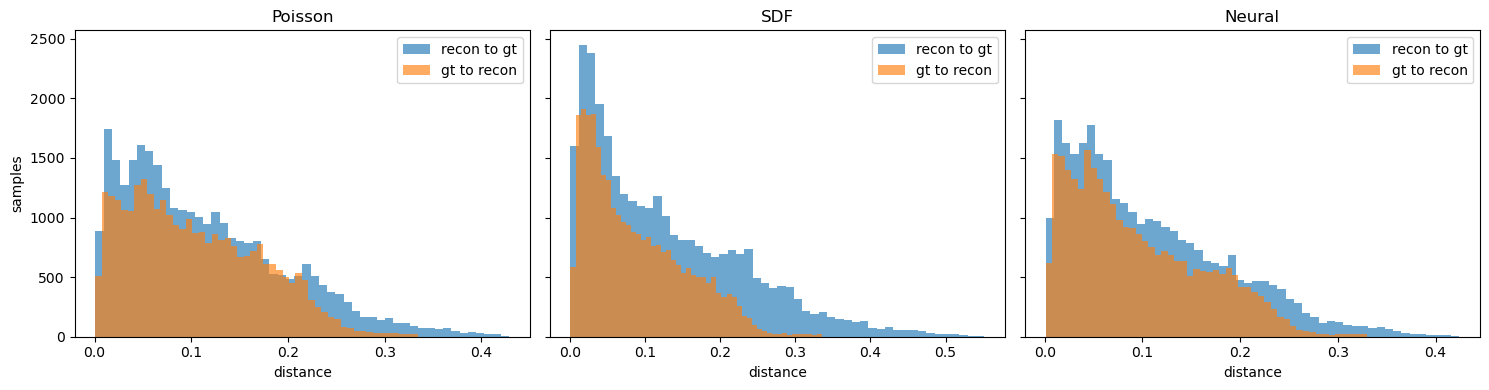

In [25]:
ground_truth_path = ROOT / paths["ground_truth_mesh"]
sample_count      = 30000
recon_base        = ROOT / paths["reconstructed_mesh"]

candidates = {
    "Poisson": recon_base.with_name(recon_base.stem + "_poisson" + recon_base.suffix),
    "SDF":     recon_base,
    "Neural":  recon_base.with_name(recon_base.stem + "_neural" + recon_base.suffix),
}

if not ground_truth_path.exists():
    print(f"Ground truth mesh not found: {ground_truth_path}")
else:
    o3d.utility.random.seed(42)
    gt_sample = reconstruct_module.sample_mesh(str(ground_truth_path), sample_count)

    results = {}
    for method, mp in candidates.items():
        if not mp.exists():
            print(f"{method}: mesh not found, skipping")
            continue
        recon_s = reconstruct_module.sample_mesh(str(mp), sample_count)
        gt_a    = reconstruct_module.align_by_centroid_scale(gt_sample, recon_s)
        gt_a    = reconstruct_module.align_by_icp(gt_a, recon_s)
        d_r2g   = np.asarray(recon_s.compute_point_cloud_distance(gt_a))
        d_g2r   = np.asarray(gt_a.compute_point_cloud_distance(recon_s))
        results[method] = (d_r2g, d_g2r)
        chamfer = (d_r2g.mean() + d_g2r.mean()) / 2
        print(f"{method:10s}  chamfer={chamfer:.5f}  r->gt={d_r2g.mean():.5f}  gt->r={d_g2r.mean():.5f}")

    if results:
        fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
        if len(results) == 1:
            axes = [axes]
        for ax, (method, (d_r2g, d_g2r)) in zip(axes, results.items()):
            ax.hist(d_r2g, bins=50, alpha=0.65, label="recon to gt")
            ax.hist(d_g2r, bins=50, alpha=0.65, label="gt to recon")
            ax.set_title(method)
            ax.set_xlabel("distance")
            ax.legend()
        axes[0].set_ylabel("samples")
        plt.tight_layout()
